In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import itertools 
from scipy.stats import skew


In [49]:
def simulate_profit_all_k(df_day, fstar_col='choice_fstar', odds_col='choice_decimal_odds', n_samples=50000, max_combos=50000):

    probs = df_day['choice_proba'].values
    fstar = df_day[fstar_col].values
    odds = df_day[odds_col].values
    n = len(probs)

    pmf_vals = np.array([poisson_binomial_pmf(probs, k) for k in range(n+1)])
    pmf_vals /= pmf_vals.sum()
    k_values = np.arange(n+1)

    profits = []

    for _ in range(n_samples):
            # --- add noise to probabilities per trial ---
            eps = 1e-6
            probs_noisy = np.clip(
                probs + np.random.normal(0, 0.08, size=probs.shape),
                eps, 1 - eps
            )
            
            # --- compute Poisson-Binomial PMF with noisy probabilities ---
            pmf_vals = np.array([poisson_binomial_pmf(probs_noisy, k) for k in range(n+1)])
            pmf_vals /= pmf_vals.sum()  # normalize
            
            # --- sample number of wins ---
            k = np.random.choice(k_values, p=pmf_vals)
            
            # --- choose k bets based on weighted probabilities ---
            weights = probs_noisy / (1 - probs_noisy)
            chosen = np.random.choice(n, size=k, replace=False, p=weights / weights.sum())

            wins = np.zeros(n, dtype=bool)
            wins[chosen] = True

            # --- calculate profit ---
            profit = np.sum(wins * (fstar * (odds - 1)) + (~wins) * (-fstar))
            profits.append(profit)
    
    profits = np.array(profits)

    mean_profit = profits.mean()
    skew_profit = skew(profits)
    prob_loss = np.mean(profits < 0)
    expected_k = np.sum(pmf_vals * k_values)

    plt.figure(figsize=(8,5))
    plt.hist(profits, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(mean_profit, color='red', linestyle='--', label=f'Mean: {mean_profit:.2f}')
    plt.title(
        f"Profit Distribution (Mean={mean_profit:.2f}, "
        f"Skew={skew_profit:.2f}, P(Loss)={prob_loss:.2f}, "
        f"E[k]={expected_k:.2f})" 
        f"Net Odds: {df_day['event_net_odds'].iloc[0]:.2f}"
    )
    plt.xlabel("Profit")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
    return profits

def pmf_num_wins(df):

    # Filter positive EV only
    pos_df = df[(df['choice_ev'] > 0) & (df['choice_fstar'] > 0)] # criteria for bets placed

    # Group by date
    groups = pos_df.groupby('date')

    n_bets = []
    max_likelihood_k = []
    max_proba_k = []
    net_odds_per_day = []
    pos_dates = []

    for date, g in groups:

        probs = g['choice_proba'].values
        k_total = len(probs)
        n_bets.append(k_total)

        # compute pmf values for all k 
        pmf_vals = [poisson_binomial_pmf(probs, k) for k in range(k_total + 1)]

        # most likely k
        best_k = np.argmax(pmf_vals)
        max_likelihood_k.append(best_k)
        max_proba_k.append(pmf_vals[best_k])

        # average net odds for the same day
        net_odds_per_day.append(g['event_net_odds'].mean())

        # store valid dates 
        pos_dates.append(date)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

    # ---- Histogram subplot ----
    sns.histplot(max_likelihood_k, kde=True, bins=20, ax=axes[0])
    axes[0].set_title("Most likely number of wins per day")
    axes[0].set_xlabel("# Wins (argmax pmf)")
    axes[0].set_ylabel("Frequency")

    # ---- Average net odds grouped by predicted wins ----
    df_plot = pd.DataFrame({
        "argmax_wins": max_likelihood_k,
        "net_odds": net_odds_per_day,
        'wins_proba': max_proba_k,
        'n_bets': n_bets,
        'date': pos_dates
    })

    grouped_df = df_plot.groupby("argmax_wins")["net_odds"].mean().reset_index()

    # ---- Bar chart subplot ----
    sns.barplot(data=grouped_df, x="argmax_wins", y="net_odds", ax=axes[1])
    axes[1].set_title("Mean Net Odds by Most Likely Wins")
    axes[1].set_xlabel("Most Likely Wins (per day)")
    axes[1].set_ylabel("Mean Net Odds (per day)")

    sns.barplot(data=df_plot, x='n_bets', y='net_odds', ax=axes[2])
    axes[2].set_title("Mean Net Odds by Number of Bets Placed")
    axes[2].set_xlabel("Number of Bets Placed (per day)")
    axes[2].set_ylabel("Mean Net Odds (per day)")

    plt.tight_layout()
    plt.show()

    return max_likelihood_k, net_odds_per_day, df_plot


def poisson_binomial_pmf(probs, k):
    """
    probs : list or array of success probabilities p_i
    k     : number of total successes in the sum
    """
    # Start distribution at P(X=0) = 1
    pmf = np.array([1.0])
    
    # Convolution process
    for p in probs:
        pmf = np.convolve(pmf, [1-p, p])
    
    return pmf[k]



In [ ]:

def prob_profit_mc(p, odds, fstar, sigma=.05, n_sims=10000):

    p = np.array(p)
    odds = np.array(odds)
    n = len(p)

    profits = np.zeros(n_sims)

    for s in range(n_sims):

        p_sample = np.random.normal(p, sigma)
        p_sample = np.clip(p_sample, 0, 1)

        # sample k wins across all bets
        wins = np.random.rand(n) < p_sample

        # profit calc
        profit = np.sum(
            wins * (fstar * (odds-1)) + (~wins) * (-fstar)
        )

        profits[s] = profit

    return profits


def min_wins_for_profit(p, odds, fstar, sigma=0.05, n_sims=10000):

    p = np.array(p)
    odds = np.array(odds)
    n = len(p)

    results = []

    for _ in range(n_sims):

        # noisy probabilities
        p_sample = np.random.normal(p, sigma)
        p_sample = np.clip(p_sample, 0, 1)

        # simulate outcomes
        wins = np.random.randn(n) < p_sample

        # compute profit per bet
        profit_i = wins * (fstar * odds) + (~wins) * (-fstar)
        profit_i = profit_i.values
        # running cumulative profit sorted by biggest edge first
        idx = np.argsort(-(fstar * odds))  # profitable bets first

        cum_profit = np.cumsum(profit_i[idx])

        # find minimum k that turns profit > 0
        profitable = np.where(cum_profit > 0)[0]

        if len(profitable) > 0:
            k_min = profitable[0] + 1

        results.append(k_min)

    return np.mean(results), results


def event_analysis(df_, n_bins=20):
    df = df_.copy()

    df['date'] = pd.to_datetime(df['date'])

    avg_ev_per = df[df['choice_ev']>0].groupby('date')['choice_ev'].mean()
    bets_per = df[df['choice_ev'] > 0].groupby('date')['choice_ev'].count()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram 1: avg EV per day
    sns.histplot(avg_ev_per, kde=True, bins=20, ax=axes[0])
    axes[0].set_title(f"Avg EV per day (mean={avg_ev_per.mean():.3f})")
    axes[0].set_xlabel("Avg Choice EV")
    axes[0].set_ylabel("Frequency")

    # Histogram 2: bets per day
    sns.histplot(bets_per, kde=True, bins=20, ax=axes[1])
    axes[1].set_title(f"Bets per day (mean={bets_per.mean():.3f})")
    axes[1].set_xlabel("# of Positive EV Bets per Day")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    return avg_ev_per, bets_per


In [4]:
df_parlay_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')
df_kelly_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\results_data\kelly_open.csv')

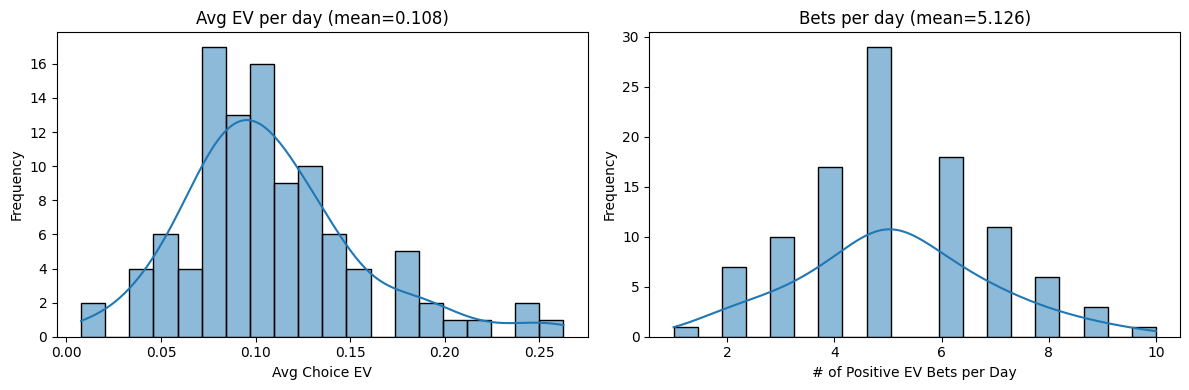

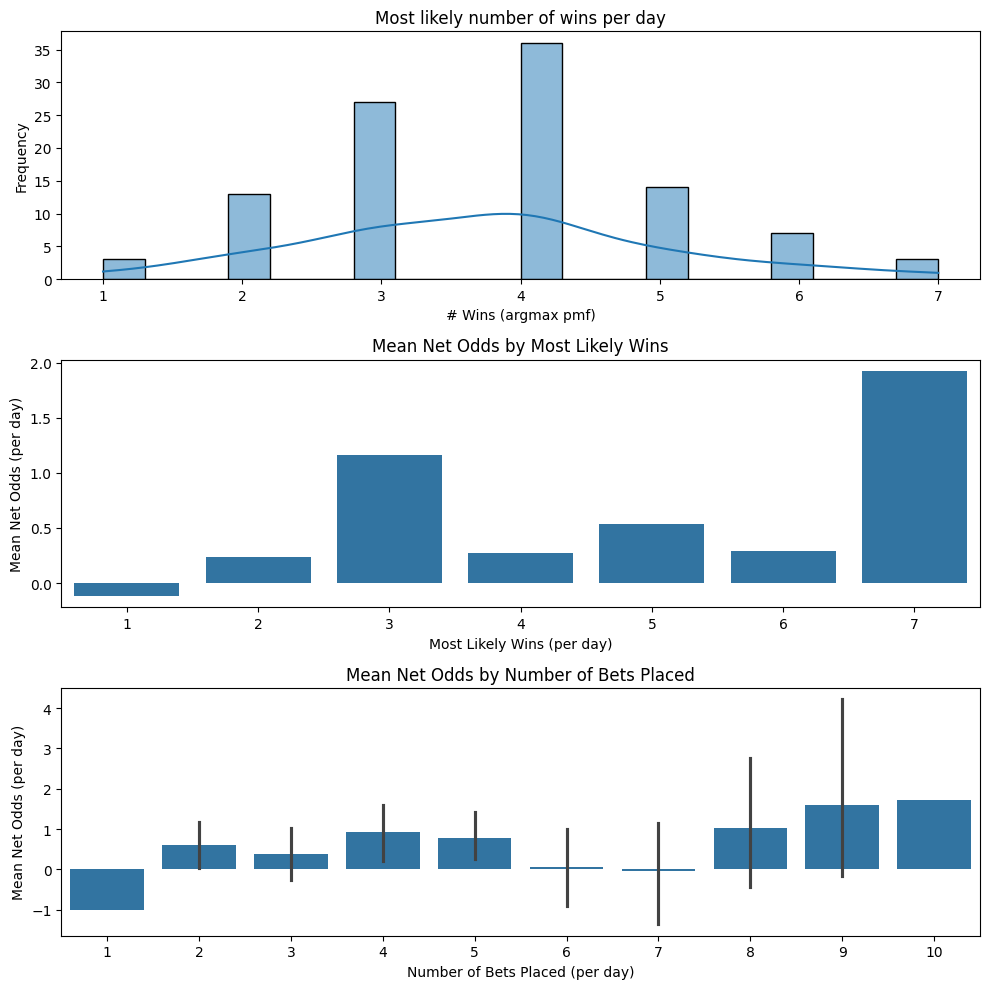

In [46]:
avg_ev_per, bets_per = event_analysis(df_kelly_open)
max_likelihood_k, net_odds_per_day, df_pmf = pmf_num_wins(df_kelly_open)

In [13]:
df_parlay_open[['choice_real_odds', 'parlay_net_odds']]

,choice_real_odds,parlay_net_odds
0,1.724638,0.000000
1,1.363636,1.662338
2,1.952381,1.662338
3,1.266667,-1.000000
4,2.050000,-1.000000
...,...,...
202,1.645161,1.175858
203,1.303030,-1.000000
204,1.400000,-1.000000
205,2.300000,2.833333


In [24]:
df_parlay_open['date'] = pd.to_datetime(df_parlay_open['date'])
df_parlay = pd.merge(df_parlay_open, df_pmf, left_on='date', right_on='date', how='left')
df_parlay['parlay_win'] = np.where(df_parlay['parlay_net_odds'] > 0, 1, 0)
df_parlay['parlay_proba'] = df_parlay.groupby('date')['choice_proba'].transform(lambda x: np.prod(x))
df_parlay['parlay_odds'] = df_parlay.groupby('date')['choice_real_odds'].transform(lambda x: np.prod(x)-1)

df_parlay['parlay_ev'] = df_parlay['parlay_proba'] * df_parlay['parlay_odds'] - (1 - df_parlay['parlay_proba'])

grouped = (
    df_parlay.groupby("date", as_index=False)
      .agg({
          "choice_proba": "mean",
          "choice_ev": "mean",
      })
)

grouped = grouped.rename(columns={
    "choice_proba": "avg_choice_proba",
    "choice_ev": "avg_choice_ev",
})

df_parlay = pd.merge(df_parlay, grouped, on="date")
df_parlay = df_parlay.dropna().groupby("date").first().reset_index()


In [25]:
df_parlay['parlay_ev']

0      0.230681
1      0.148003
2      0.670466
3      0.254103
4      0.223484
         ...   
98     0.325379
99     0.491932
100    0.314095
101    0.449898
102    0.390179
Name: parlay_ev, Length: 103, dtype: float64

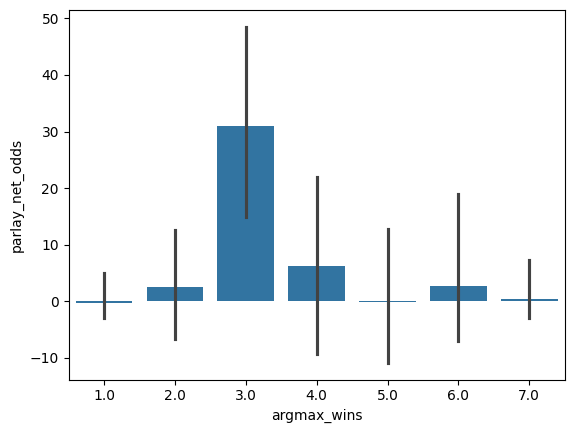

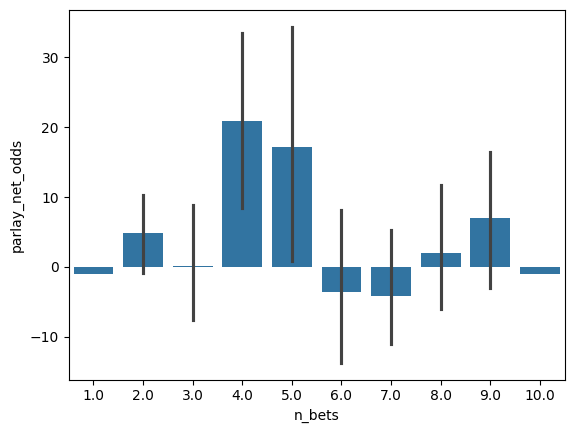

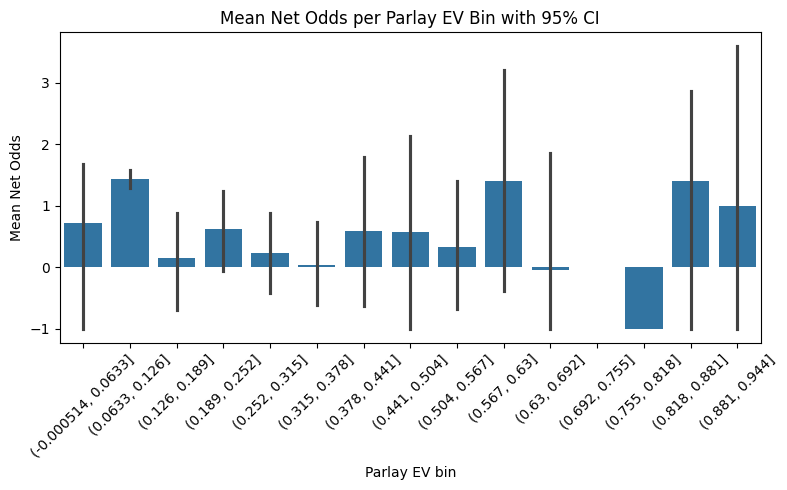

In [30]:
sns.barplot(data=df_parlay, x='argmax_wins', y='parlay_net_odds', estimator=np.sum)
plt.show()

sns.barplot(data=df_parlay, x='n_bets', y='parlay_net_odds', estimator=np.sum)
plt.show()

n_bins = 15  # adjust as needed
df_parlay['ev_bin'] = pd.cut(df_parlay['parlay_ev'], bins=n_bins)

# --- plot with Seaborn ---
plt.figure(figsize=(8,5))
sns.barplot(
    x='ev_bin', 
    y='parlay_net_odds', 
    data=df_parlay, 
    estimator=np.mean,      # mean per bin
    errorbar=('ci', 95)                 # 95% confidence interval
)

plt.xticks(rotation=45)
plt.xlabel('Parlay EV bin')
plt.ylabel('Mean Net Odds')
plt.title('Mean Net Odds per Parlay EV Bin with 95% CI')
plt.tight_layout()
plt.show()

In [60]:
split_size = int(0.8 * len(df_parlay))
df_parlay_train = df_parlay.iloc[:split_size].dropna().groupby("date").first().reset_index()
df_parlay_test = df_parlay.iloc[split_size:].dropna().groupby("date").first().reset_index()
feats = ['avg_choice_proba', 'avg_choice_ev', 'argmax_wins', 'wins_proba', 'n_bets', 'parlay_fstar_sum']
X_train = df_parlay_train[feats]
y_train = df_parlay_train['parlay_win']

X_test = df_parlay_test[feats]
y_test = df_parlay_test['parlay_win']

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

rf = RandomForestClassifier(n_estimators=900, max_depth=5, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(rf.score(X_test, y_test))
print("Accuracy:", acc)

importances = rf.feature_importances_
feature_names = X_train.columns  # or your list of names

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(fi)

0.38095238095238093
Accuracy: 0.38095238095238093
parlay_fstar_sum    0.221771
avg_choice_proba    0.221703
avg_choice_ev       0.208864
wins_proba          0.205501
n_bets              0.074807
argmax_wins         0.067354
dtype: float64


In [20]:
df_kelly_open['event_net_odds'] 

0      0.000000
1      1.116318
2      1.116318
3      1.116318
4      1.116318
         ...   
921    1.366667
922    1.366667
923    1.366667
924    1.366667
925    1.366667
Name: event_net_odds, Length: 926, dtype: float64

In [72]:
groups = df_kelly_open.groupby('date')
for date, g in groups:
    if g.shape[0] > 15: 
        print(date, g.shape[0])
        print(g.head(25)[['fighter_red', 'red_proba', 'event_net_odds']])

2025-11-01 24
             fighter_red  red_proba  event_net_odds
857       charles radtke   0.515514        0.766667
858     allan nascimento   0.751836        0.766667
859  waldo cortes acosta   0.437225        0.766667
860         timmy cuamba   0.560283        0.766667
861      isaac dulgarian   0.762951        0.766667
862            phil rowe   0.425604        0.766667
863            phil rowe   0.400039        0.766667
864       talita alencar   0.714603        0.766667
865        ketlen vieira   0.440561        0.766667
866       alice ardelean   0.785294        0.766667
867       jeremiah wells   0.347798        0.766667
868         steve garcia   0.630263        0.766667
869         steve garcia   0.661969        0.766667
870       charles radtke   0.525186        0.766667
871  waldo cortes acosta   0.404500        0.766667
872       jeremiah wells   0.333419        0.766667
873     allan nascimento   0.746323        0.766667
874        billy elekana   0.715047        0.76666

In [ ]:
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from diptest import diptest

def event_profit_sim(df_kelly_open):
    groups = df_kelly_open.groupby('date')

    mean_profits = []
    vars_profits = []
    skews_profits = []  
    kurtosis_profits = []
    prob_losses = []
    entropy_profits = []
    date_list = []
    sparsity_fractions = []
    peaks_profits = []
    modimodality_pvals = []

    for date, g in groups:

        g_filtered = g[(g['choice_ev'] > 0) & (g['choice_fstar'] > 0)]
        if g_filtered.empty:
            continue  # skip this date if no positive bets

        profits = simulate_profit_all_k(g_filtered, fstar_col='choice_fstar', odds_col='choice_decimal_odds', n_samples=10000, max_combos=50000)
        mean_profits.append(np.mean(profits))
        vars_profits.append(np.var(profits))
        skews_profits.append(skew(profits)) 
        kurtosis_profits.append(kurtosis(profits))
        prob_losses.append(np.sum(profits < 0) / len(profits))
        date_list.append(date)

        hist, bin_edges = np.histogram(profits, bins=50, density=True)
        p = hist[hist >0]
        entropy = -np.sum(p * np.log(p)) if len(p) > 0 else 0
        entropy_profits.append(entropy)

        gap_fraction = np.mean(hist < 1e-6)
        sparsity_fractions.append(gap_fraction)

        peaks, _ = find_peaks(hist)
        n_modes = len(peaks)
        peaks_profits.append(n_modes)

        # dip, p_value = diptest(profits)
        # print('dip p-value:', p_value)
        # modimodality_pvals.append(p_value)

    df_dist = pd.DataFrame({
        'date': date_list, 'mean_profit': mean_profits,
        'var_profit': vars_profits, 'skew_profit': skews_profits,
        'kurtosis_profit': kurtosis_profits, 'prob_loss': prob_losses,
        'entropy_profit': entropy_profits, 'sparsity_fraction': sparsity_fractions,
        'n_peaks_profit': peaks_profits })
    return df_dist


df_dist = event_profit_sim(df_kelly_open)

(array([    0.,     0.,     0.,     0.,     0., 10000.,     0.,     0.,
            0.,     0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

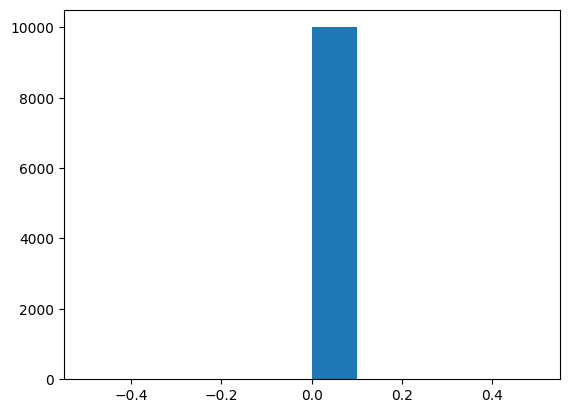

In [7]:
from scipy.stats import skew, kurtosis

# def event_profit_sim(df_kelly_open):
#     g = df_kelly_open.groupby('date')



w_fight = df_kelly_open[(df_kelly_open['date']=='2025-10-04	') & (df_kelly_open['choice_ev']>0)]
p = w_fight['choice_proba']
odds = w_fight['choice_decimal_odds']
fstar = w_fight['choice_fstar']
profits = prob_profit_mc(p, odds, fstar)
# avg_k_min, results = min_wins_for_profit(p, odds, fstar)

p_lose = np.sum(profits < 0 ) / len(profits)
mean_win = np.mean(profits)
plt.hist(profits)

In [14]:
df_parlay_open.tail(20)

,Unnamed: 0,choice_fighter_name,parlay_fstar_sum,parlay_net_odds,choice_fstar,choice_ev,choice_real_odds,date,winner,pred_winner,choice_proba
187,0,magomed ankalaev,0.153038,-1.000000,0.053842,0.144953,1.555556,2025-10-04,0.0,1,0.736041
188,1,merab dvalishvili,0.153038,-1.000000,0.099196,0.143536,1.259740,2025-10-04,1.0,1,0.907756
189,0,michael aswell jr,0.108916,-1.000000,0.045799,0.157792,1.714286,2025-10-11,0.0,0,0.675379
190,5,montel jackson,0.108916,-1.000000,0.063116,0.144923,1.444444,2025-10-11,1.0,0,0.792639
191,7,charles jourdain,0.098628,1.586957,0.055646,0.095257,1.500000,2025-10-18,1.0,1,0.730172
192,0,aiemann zahabi,0.098628,1.586957,0.042981,0.050128,1.724638,2025-10-18,0.0,0,0.608898
193,5,ludovit klein,0.066961,-1.000000,0.032318,0.249275,2.300000,2025-10-25,1.0,1,0.543163
194,4,aleksandar rakic,0.066961,-1.000000,0.034643,0.224319,2.150000,2025-10-25,0.0,1,0.569451
195,3,timmy cuamba,0.058138,5.502500,0.029148,0.428720,2.550000,2025-11-01,1.0,1,0.560283
196,22,timmy cuamba,0.058138,5.502500,0.028991,0.360763,2.550000,2025-11-01,1.0,1,0.533633
